# 🔬 Minería de Datos — Unidad 2 · Clase 2
## Laboratorio: Tipos de Datos y Estadística Descriptiva con Pandas

**Tecnicatura en Cs de Datoa e IA — Politécnico Malvinas Argentinas — 2026**

---

### Objetivos del laboratorio

- Inspeccionar tipos de datos con `.dtypes` e `.info()`
- Convertir tipos con `.astype()` para optimizar memoria y semántica
- Calcular estadísticas descriptivas: media, mediana, moda, varianza, IQR
- Visualizar distribuciones con histogramas y boxplots
- Detectar outliers usando la regla del IQR

### Dataset
Trabajamos con el **Titanic** — un clásico del análisis de datos con variables de todos los tipos.

| Columna | Descripción | Tipo estadístico |
|---------|------------|------------------|
| PassengerId | ID único del pasajero | Nominal (ID) |
| Survived | Sobrevivió (0=No, 1=Sí) | Nominal binario |
| Pclass | Clase del pasaje (1, 2, 3) | Ordinal |
| Name | Nombre completo | Nominal |
| Sex | Sexo | Nominal |
| Age | Edad en años | Continua |
| SibSp | Hermanos/cónyuge a bordo | Discreta |
| Parch | Padres/hijos a bordo | Discreta |
| Ticket | Número de ticket | Nominal |
| Fare | Precio del pasaje | Continua |
| Cabin | Número de cabina | Nominal |
| Embarked | Puerto de embarque (C, Q, S) | Nominal |

---
## 📦 Sección 1: Setup e importación del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='Set2')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# Cargar dataset Titanic
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'Dataset cargado exitosamente.')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Dataset cargado exitosamente.
Dimensiones: 891 filas x 12 columnas


In [3]:
# Vista previa de las primeras filas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Vista previa de las últimas filas
df.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
# Columnas disponibles
print('Columnas:', list(df.columns))
print()

# Valores nulos por columna
nulos = df.isnull().sum()
pct_nulos = (df.isnull().mean() * 100).round(1)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos
}).query('Nulos > 0')

print('Columnas con valores nulos:')
print(resumen_nulos)

Columnas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Columnas con valores nulos:
          Nulos  Porcentaje (%)
Age         177            19.9
Cabin       687            77.1
Embarked      2             0.2


---
## 🔍 Sección 2: Explorar tipos de datos

> **Recordar:** el tipo en Pandas (`int64`, `float64`, `object`) no siempre coincide con el tipo estadístico (nominal, ordinal, discreta, continua).

In [6]:
# Tipos de datos asignados automáticamente por Pandas
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [7]:
# .info() — vista completa: tipos, no-nulos, memoria
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# Memoria usada por el DataFrame completo
memoria_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memoria total: {memoria_mb:.3f} MB')

Memoria total: 0.279 MB


### 🤔 Reflexión: ¿El tipo de dato coincide con el tipo estadístico?

Completá la tabla con tu análisis:

| Columna | dtype Pandas | Tipo estadístico | ¿El dtype es adecuado? |
|---------|-------------|-------------------|------------------------|
| PassengerId | int64 | Nominal (ID) | Sí |
| Survived | int64 | Nominal binario | No |
| Pclass | int64 | Ordinal |No  |
| Sex | object | Nominal | Sí  |
| Age | float64 | Continua | Sí  |
| Fare | float64 | Continua| Sí  |



---
## 🔄 Sección 3: Convertir tipos con `.astype()`

Vamos a convertir columnas para que reflejen correctamente su tipo estadístico y para optimizar el uso de memoria.

In [9]:
# Memoria ANTES de convertir
memoria_antes = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memoria antes: {memoria_antes:.3f} MB')
print()
print('Tipos actuales:')
print(df.dtypes)

Memoria antes: 0.279 MB

Tipos actuales:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [10]:
# Convertir tipos

# Survived: int64 -> bool (es binario: True/False)
df['Survived'] = df['Survived'].astype(bool)

# Pclass: int64 -> category (es ordinal: 1 < 2 < 3)
df['Pclass'] = df['Pclass'].astype('category')

# Sex: object -> category (pocos valores únicos)
df['Sex'] = df['Sex'].astype('category')

# Embarked: object -> category
df['Embarked'] = df['Embarked'].astype('category')

print('Tipos DESPUÉS de convertir:')
print(df[['Survived','Pclass','Sex','Embarked']].dtypes)

Tipos DESPUÉS de convertir:
Survived        bool
Pclass      category
Sex         category
Embarked    category
dtype: object


In [11]:
# Memoria DESPUÉS de convertir
memoria_despues = df.memory_usage(deep=True).sum() / 1024**2
ahorro = (1 - memoria_despues / memoria_antes) * 100

print(f'Memoria antes:  {memoria_antes:.3f} MB')
print(f'Memoria después: {memoria_despues:.3f} MB')
print(f'Ahorro: {ahorro:.1f}%')

Memoria antes:  0.279 MB
Memoria después: 0.181 MB
Ahorro: 35.0%


In [12]:
# Ver categorías de las columnas category
print('Categorías de Sex:     ', df['Sex'].cat.categories.tolist())
print('Categorías de Pclass:  ', df['Pclass'].cat.categories.tolist())
print('Categorías de Embarked:', df['Embarked'].cat.categories.tolist())

Categorías de Sex:      ['female', 'male']
Categorías de Pclass:   [1, 2, 3]
Categorías de Embarked: ['C', 'Q', 'S']


### ✏️ Actividad 1: Comparar memoria

**Completá el código para responder:**

1. ¿Cuánto ahorro de memoria lograron las conversiones?
2. ¿Qué columna tenía el mayor tamaño antes de convertir?

```python
# TODO: Ver el uso de memoria POR COLUMNA antes y después
# Pista: df.memory_usage(deep=True)
```

In [13]:
# TODO: Completá aquí
# Calculá el uso de memoria por columna y mostrá las 5 más pesadas
# Antes de las conversiones (si guardaste el df original) o después

memoria_por_col = df.memory_usage(deep=True).sort_values(ascending=False)
print('Top 5 columnas por memoria (bytes):')
print(memoria_por_col.head(6))  # head(6) porque la primera fila es el Index

Top 5 columnas por memoria (bytes):
Name           67685
Ticket         49674
Cabin          32712
PassengerId     7128
Age             7128
Fare            7128
dtype: int64


### Respuestas
1. El ahorro de memoria fue aproximadamente del 35%. Esto muestra que la conversión de tipos de datos permitió optimizar el uso de memoria del DataFrame, especialmente en columnas categóricas como `Survived`, `Pclass`, `Sex` y `Embarked`.

2. La columna que tenía mayor tamaño en memoria fue `Name`, con 67685 bytes. Esto se debe a que contiene texto y cada valor ocupa más espacio que las variables numéricas o categóricas.

---
## 📊 Sección 4: Estadística descriptiva

### 4.1 describe() — panorama completo

In [14]:
# Estadísticas para columnas numéricas
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# Estadísticas para columnas categóricas
df.describe(include=['category', 'object', 'bool'])

,Survived,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891,204,889
unique,2,3,891,2,681,147,3
top,False,3,"Dooley, Mr. Patrick",male,347082,G6,S
freq,549,491,1,577,7,4,644


In [16]:
# Estadísticas detalladas solo para Age
print('=== Análisis de Age ===')
print(df['Age'].describe())
print()
print(f'Valores no nulos: {df["Age"].count()} de {len(df)}')
print(f'Valores nulos:    {df["Age"].isnull().sum()}')

=== Análisis de Age ===
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Valores no nulos: 714 de 891
Valores nulos:    177


### 4.2 Medidas de tendencia central y dispersión

In [17]:
# ─── TENDENCIA CENTRAL para Age ───
col = df['Age']

media   = col.mean()
mediana = col.median()
moda    = col.mode()[0]

print(f'Media:   {media:.2f}')
print(f'Mediana: {mediana:.2f}')
print(f'Moda:    {moda:.2f}')
print()
diferencia = abs(media - mediana)
print(f'Diferencia media-mediana: {diferencia:.2f}')
print('(Valor cercano a 0 indica distribución simétrica)')

Media:   29.70
Mediana: 28.00
Moda:    24.00

Diferencia media-mediana: 1.70
(Valor cercano a 0 indica distribución simétrica)


In [18]:
# ─── DISPERSIÓN para Age ───
col = df['Age']

rango    = col.max() - col.min()
varianza = col.var()
std      = col.std()
Q1       = col.quantile(0.25)
Q3       = col.quantile(0.75)
IQR      = Q3 - Q1

print(f'Rango:    {rango:.2f}')
print(f'Varianza: {varianza:.2f}')
print(f'Std:      {std:.2f}')
print(f'Q1:       {Q1:.2f}')
print(f'Q3:       {Q3:.2f}')
print(f'IQR:      {IQR:.2f}')

Rango:    79.58
Varianza: 211.02
Std:      14.53
Q1:       20.12
Q3:       38.00
IQR:      17.88


In [19]:
# Estadísticas personalizadas para múltiples columnas
cols_num = ['Age', 'Fare', 'SibSp', 'Parch']
resumen = df[cols_num].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print('Resumen estadístico personalizado:')
print(resumen)

Resumen estadístico personalizado:
          Age    Fare  SibSp  Parch
mean    29.70   32.20   0.52   0.38
median  28.00   14.45   0.00   0.00
std     14.53   49.69   1.10   0.81
min      0.42    0.00   0.00   0.00
max     80.00  512.33   8.00   6.00


### ✏️ Actividad 2: Análisis de Fare

Calculá las mismas estadísticas para la columna `Fare`.

**Preguntas a responder:**
1. ¿La media es mayor, menor o igual a la mediana? ¿Qué indica eso?
2. ¿Es grande el desvío estándar comparado con la media?
3. ¿Cuánto vale el IQR?

In [41]:
# TODO: Calculá media, mediana, moda, std, Q1, Q3 e IQR para 'Fare'
# Usá las mismas líneas de código que usamos para 'Age'



col_fare = df['Fare']


media_fare = col_fare.mean()
mediana_fare = col_fare.median()
moda_fare = col_fare.mode()[0]
std_fare = col_fare.std()

Q1 = col_fare.quantile(0.25)
Q3 = col_fare.quantile(0.75)
IQR_fare = Q3 - Q1

# Resultados
print("Estadísticas de Fare:\n")
print(f"Media Fare: {media_fare:.2f}")
print(f"Mediana Fare: {mediana_fare:.2f}")
print(f"Moda Fare: {moda_fare:.2f}")
print(f"Std Fare: {std_fare:.2f}")
print(f"Q1 Fare: {Q1:.2f}")
print(f"Q3 Fare: {Q3:.2f}")
print(f"IQR Fare: {IQR_fare:.2f}")

Estadísticas de Fare:

Media Fare: 32.20
Mediana Fare: 14.45
Moda Fare: 8.05
Std Fare: 49.69
Q1 Fare: 7.91
Q3 Fare: 31.00
IQR Fare: 23.09


---
## 📈 Sección 5: Visualizaciones

### 5.1 Histograma de Age

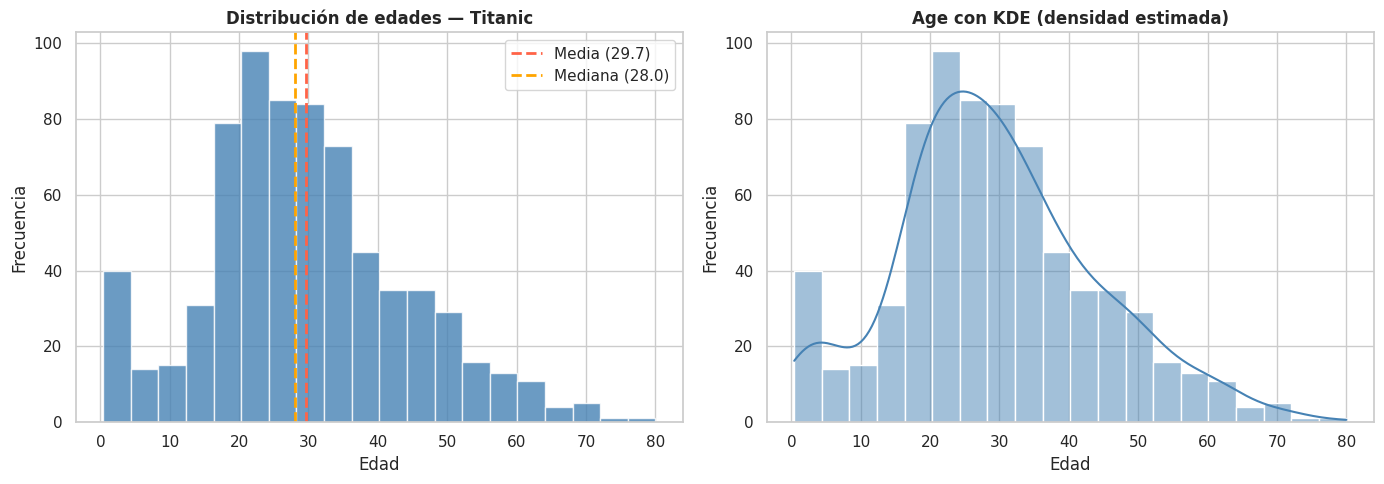

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histograma matplotlib ──
ax = axes[0]
ax.hist(df['Age'].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df['Age'].mean(),   color='tomato',  linestyle='--', lw=2, label=f'Media ({df["Age"].mean():.1f})')
ax.axvline(df['Age'].median(), color='orange',  linestyle='--', lw=2, label=f'Mediana ({df["Age"].median():.1f})')
ax.set_xlabel('Edad')  ;  ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de edades — Titanic', fontweight='bold')
ax.legend()

# ── Histograma seaborn con KDE ──
sns.histplot(data=df, x='Age', bins=20, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('Age con KDE (densidad estimada)', fontweight='bold')
axes[1].set_xlabel('Edad')  ;  axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

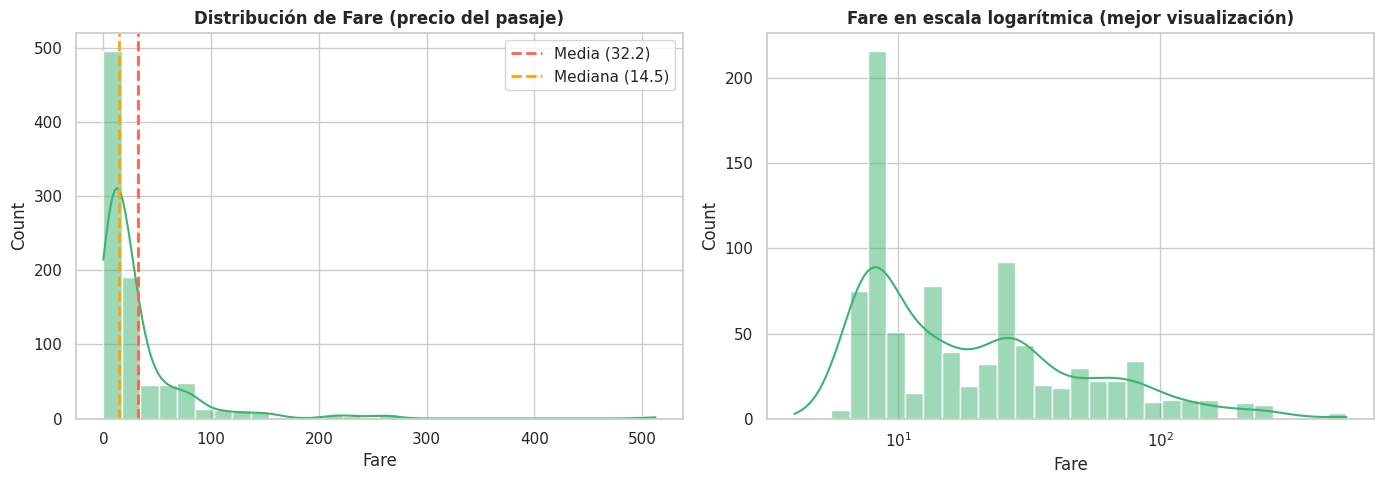

Observar: la diferencia entre media y mediana indica fuerte sesgo a la derecha.


In [22]:
# Histograma de Fare — para observar el sesgo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Fare', bins=30, kde=True, color='mediumseagreen', ax=axes[0])
axes[0].axvline(df['Fare'].mean(),   color='tomato', linestyle='--', lw=2,
                label=f'Media ({df["Fare"].mean():.1f})')
axes[0].axvline(df['Fare'].median(), color='orange', linestyle='--', lw=2,
                label=f'Mediana ({df["Fare"].median():.1f})')
axes[0].set_title('Distribución de Fare (precio del pasaje)', fontweight='bold')
axes[0].legend()

# Escala logarítmica para ver mejor la distribución
df_fare = df[df['Fare'] > 0]
sns.histplot(data=df_fare, x='Fare', bins=30, kde=True,
             color='mediumseagreen', ax=axes[1], log_scale=True)
axes[1].set_title('Fare en escala logarítmica (mejor visualización)', fontweight='bold')

plt.tight_layout()
plt.show()

print('Observar: la diferencia entre media y mediana indica fuerte sesgo a la derecha.')

### 5.2 Boxplots

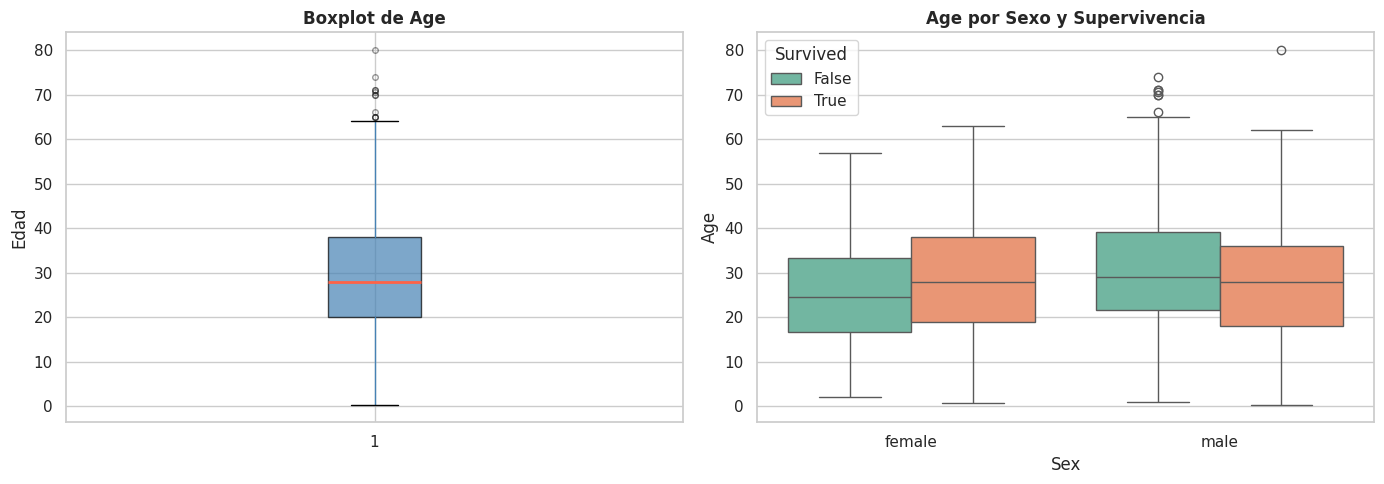

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Boxplot simple de Age ──
axes[0].boxplot(
    df['Age'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7),
    medianprops=dict(color='tomato', lw=2),
    whiskerprops=dict(color='steelblue'),
    flierprops=dict(marker='o', color='gray', alpha=0.4, markersize=4)
)
axes[0].set_title('Boxplot de Age', fontweight='bold')
axes[0].set_ylabel('Edad')

# ── Boxplot de Age comparativo por sexo ──
sns.boxplot(data=df, x='Sex', y='Age',
            hue='Survived', palette='Set2', ax=axes[1])
axes[1].set_title('Age por Sexo y Supervivencia', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_19767/3033785048.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Blues')


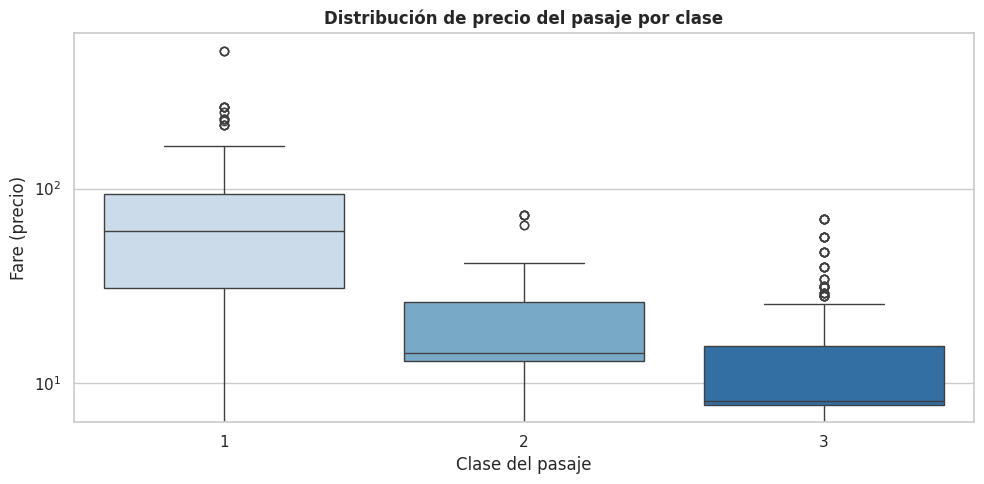

Los puntos fuera de los bigotes son outliers según la regla IQR.


In [24]:
# Boxplot de Fare por clase de pasaje
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Blues')
plt.title('Distribución de precio del pasaje por clase', fontweight='bold')
plt.xlabel('Clase del pasaje')  ;  plt.ylabel('Fare (precio)')
plt.yscale('log')  # escala log para ver mejor la distribución
plt.tight_layout()
plt.show()

print('Los puntos fuera de los bigotes son outliers según la regla IQR.')

---
## 🚨 Sección 6: Detección de outliers con la regla del IQR

### Regla de Tukey
Un valor es **outlier** si cae fuera del rango:

$$[Q1 - 1.5 \times IQR, \quad Q3 + 1.5 \times IQR]$$

In [25]:
def detectar_outliers(df, col):
    '''
    Detecta outliers usando la regla del IQR (metodo de Tukey).
    Retorna un DataFrame con los outliers encontrados.
    '''
    serie = df[col].dropna()
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]

    print(f'Columna: {col}')
    print(f'  Q1={Q1:.2f}  |  Q3={Q3:.2f}  |  IQR={IQR:.2f}')
    print(f'  Limite inferior: {lim_inf:.2f}')
    print(f'  Limite superior: {lim_sup:.2f}')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% del dataset)')
    if len(outliers) > 0:
        print(f'  Valor maximo outlier: {df[col].max():.2f}')
        print(f'  Valor minimo outlier: {outliers[col].min():.2f}')
    print()
    return outliers

print('Funcion detectar_outliers() definida correctamente.')

Funcion detectar_outliers() definida correctamente.


In [26]:
# Aplicar a columna Age
outliers_age = detectar_outliers(df, 'Age')
print('Filas con outliers en Age:')
outliers_age[['Name', 'Age', 'Pclass', 'Survived']].head(10)

Columna: Age
  Q1=20.12  |  Q3=38.00  |  IQR=17.88
  Limite inferior: -6.69
  Limite superior: 64.81
  Outliers: 11 (1.2% del dataset)
  Valor maximo outlier: 80.00
  Valor minimo outlier: 65.00

Filas con outliers en Age:


,Name,Age,Pclass,Survived
33,"Wheadon, Mr. Edward H",66.0,2,False
54,"Ostby, Mr. Engelhart Cornelius",65.0,1,False
96,"Goldschmidt, Mr. George B",71.0,1,False
116,"Connors, Mr. Patrick",70.5,3,False
280,"Duane, Mr. Frank",65.0,3,False
456,"Millet, Mr. Francis Davis",65.0,1,False
493,"Artagaveytia, Mr. Ramon",71.0,1,False
630,"Barkworth, Mr. Algernon Henry Wilson",80.0,1,True
672,"Mitchell, Mr. Henry Michael",70.0,2,False
745,"Crosby, Capt. Edward Gifford",70.0,1,False


In [27]:
# Aplicar a columna Fare
outliers_fare = detectar_outliers(df, 'Fare')
print('Los pasajeros con pasaje mas caro (outliers de Fare):')
outliers_fare.nlargest(10, 'Fare')[['Name', 'Fare', 'Pclass', 'Survived']]

Columna: Fare
  Q1=7.91  |  Q3=31.00  |  IQR=23.09
  Limite inferior: -26.72
  Limite superior: 65.63
  Outliers: 116 (13.0% del dataset)
  Valor maximo outlier: 512.33
  Valor minimo outlier: 66.60

Los pasajeros con pasaje mas caro (outliers de Fare):


,Name,Fare,Pclass,Survived
258,"Ward, Miss. Anna",512.3292,1,True
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1,True
737,"Lesurer, Mr. Gustave J",512.3292,1,True
27,"Fortune, Mr. Charles Alexander",263.0000,1,False
88,"Fortune, Miss. Mabel Helen",263.0000,1,True
341,"Fortune, Miss. Alice Elizabeth",263.0000,1,True
438,"Fortune, Mr. Mark",263.0000,1,False
311,"Ryerson, Miss. Emily Borie",262.3750,1,True
742,"Ryerson, Miss. Susan Parker ""Suzette""",262.3750,1,True
118,"Baxter, Mr. Quigg Edmond",247.5208,1,False


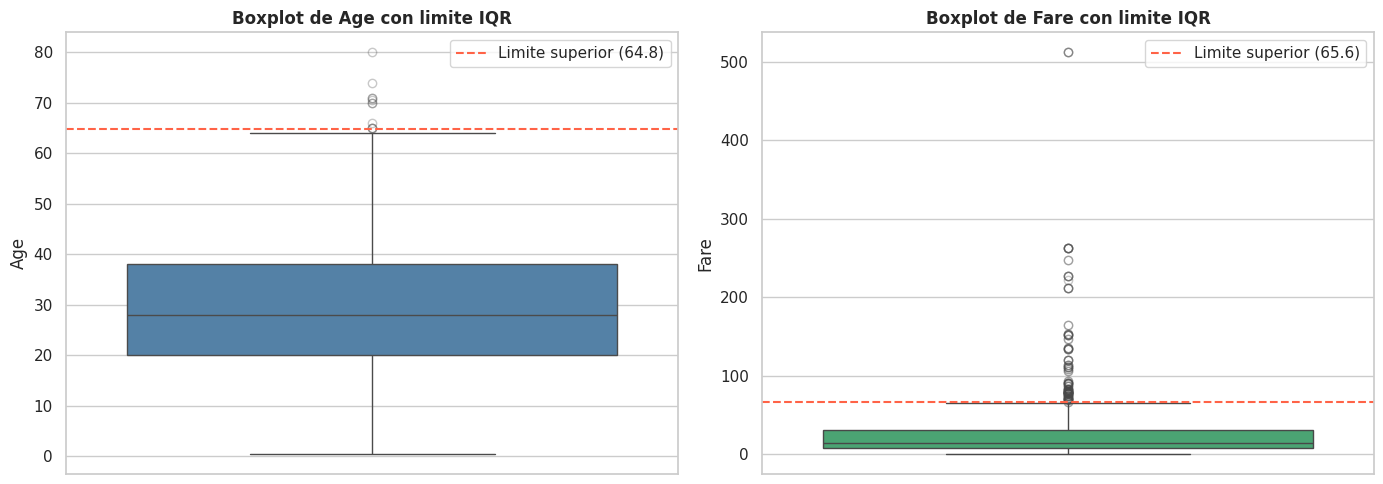

In [28]:
# Visualizar outliers en boxplot con anotaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, ['Age', 'Fare'], ['steelblue', 'mediumseagreen']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR

    sns.boxplot(data=df, y=col, color=color, ax=ax, flierprops={'alpha':0.3})
    ax.axhline(lim_sup, color='tomato', linestyle='--', lw=1.5,
               label=f'Limite superior ({lim_sup:.1f})')
    ax.set_title(f'Boxplot de {col} con limite IQR', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

### ✏️ Actividad 3: Outliers en Fare

Usando la función `detectar_outliers()`, completá el siguiente análisis:

1. ¿Cuántos outliers tiene Fare? ¿Qué porcentaje del dataset representan?
2. ¿Cuál es el pasaje más caro? ¿A qué clase pertenece ese pasajero?
3. ¿Los outliers de Fare son errores de datos o casos legítimos? Justificá.

```python
# TODO: Investigar los outliers de Fare
# Pista: ordená outliers_fare por Fare de mayor a menor
# y mostrá Name, Fare, Pclass, Cabin, Survived
```

In [29]:
# TODO: Completá este análisis
# Mostrar los 5 pasajeros con el pasaje más caro
# ¿Hay algo en común entre ellos? (clase, cabina, supervivencia)

# outliers_fare_top5 = outliers_fare.nlargest(5, 'Fare')[['Name','Fare','Pclass','Cabin','Survived']]
# print(outliers_fare_top5)


In [47]:
# Outliers en Fare

# Mostrar los 5 pasajeros con mayor Fare
outliers_fare_top5 = outliers_fare.nlargest(5, 'Fare')[['Name', 'Fare', 'Pclass', 'Cabin', 'Survived']]

print(outliers_fare_top5)

                                   Name      Fare Pclass        Cabin  \
258                    Ward, Miss. Anna  512.3292      1          NaN   
679  Cardeza, Mr. Thomas Drake Martinez  512.3292      1  B51 B53 B55   
737              Lesurer, Mr. Gustave J  512.3292      1         B101   
27       Fortune, Mr. Charles Alexander  263.0000      1  C23 C25 C27   
88           Fortune, Miss. Mabel Helen  263.0000      1  C23 C25 C27   

     Survived  
258      True  
679      True  
737      True  
27      False  
88       True  


##Análisis de outliers en Fare
Hay 116 outliers, lo que representa aproximadamente el 13% del dataset.
El pasaje más caro es 512.33 y corresponde a pasajeros de primera clase (Pclass = 1).
No son errores de datos, sino casos legítimos, ya que pertenecen a pasajeros de primera clase con tarifas más altas.

---
## 👥 Sección 7: Análisis por grupos con groupby()

In [30]:
# Estadísticas de Age y Fare por clase de pasaje
print('Media de Age y Fare por Pclass:')
print(df.groupby('Pclass')[['Age', 'Fare']].mean().round(2))

Media de Age y Fare por Pclass:
          Age   Fare
Pclass              
1       38.23  84.15
2       29.88  20.66
3       25.14  13.68


/tmp/ipykernel_19767/4003311025.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Pclass')[['Age', 'Fare']].mean().round(2))


In [31]:
# Tasa de supervivencia por sexo
surv_por_sexo = df.groupby('Sex')['Survived'].mean().round(3)
print('Tasa de supervivencia por sexo:')
print(surv_por_sexo)
print()
print('Interpretación: la proporción de 1s (True) en Survived')

Tasa de supervivencia por sexo:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Interpretación: la proporción de 1s (True) en Survived


/tmp/ipykernel_19767/1183763728.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surv_por_sexo = df.groupby('Sex')['Survived'].mean().round(3)


In [32]:
# Tabla cruzada: supervivencia x sexo (porcentaje)
tabla = pd.crosstab(df['Sex'], df['Survived'], margins=True, normalize='index')
tabla.columns = ['No sobrevivió', 'Sobrevivió']
print('Tasa de supervivencia por sexo (%):')
print((tabla * 100).round(1))

Tasa de supervivencia por sexo (%):
        No sobrevivió  Sobrevivió
Sex                              
female           25.8        74.2
male             81.1        18.9
All              61.6        38.4


In [33]:
# Estadísticas múltiples por grupo
resumen_clase = df.groupby('Pclass')['Age'].agg(
    ['mean', 'median', 'std', 'count']
).round(2)
resumen_clase.columns = ['Media', 'Mediana', 'Std', 'Count']
print('Estadísticas de Age por clase de pasaje:')
print(resumen_clase)

Estadísticas de Age por clase de pasaje:
        Media  Mediana   Std  Count
Pclass                             
1       38.23     37.0  14.8    186
2       29.88     29.0  14.0    173
3       25.14     24.0  12.5    355


/tmp/ipykernel_19767/1622976944.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_clase = df.groupby('Pclass')['Age'].agg(


---
## 🎯 Actividad Integradora: Análisis completo de Fare

Realizá un análisis completo de la columna `Fare` siguiendo todos los pasos:

1. **Verificar tipo y nulos** — dtype, cuántos nulos hay
2. **Estadísticas manuales** — media, mediana, moda, std, IQR (sin usar describe)
3. **Histograma** — con líneas de media y mediana
4. **Boxplot comparativo** — por Pclass
5. **Outliers** — aplicar función detectar_outliers
6. **Conclusiones** — escribir al menos 3 observaciones en Markdown

---

In [34]:
# PASO 1: Verificar tipo y nulos
# TODO: completar
print('Tipo de Fare:', df['Fare'].dtype)
print('Valores nulos:', df['Fare'].isnull().sum())

Tipo de Fare: float64
Valores nulos: 0


In [48]:
# PASO 2: Estadísticas manuales
# TODO: calcular media, mediana, moda, std, Q1, Q3, IQR para Fare
# (usar df['Fare'].mean(), etc.)
# PASO 2: Estadísticas manuales

col_fare = df['Fare']

media = col_fare.mean()
mediana = col_fare.median()
moda = col_fare.mode()[0]
std = col_fare.std()

Q1 = col_fare.quantile(0.25)
Q3 = col_fare.quantile(0.75)
IQR = Q3 - Q1

print("Media:", round(media, 2))
print("Mediana:", round(mediana, 2))
print("Moda:", round(moda, 2))
print("Desvío estándar:", round(std, 2))
print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))

Media: 32.2
Mediana: 14.45
Moda: 8.05
Desvío estándar: 49.69
Q1: 7.91
Q3: 31.0
IQR: 23.09


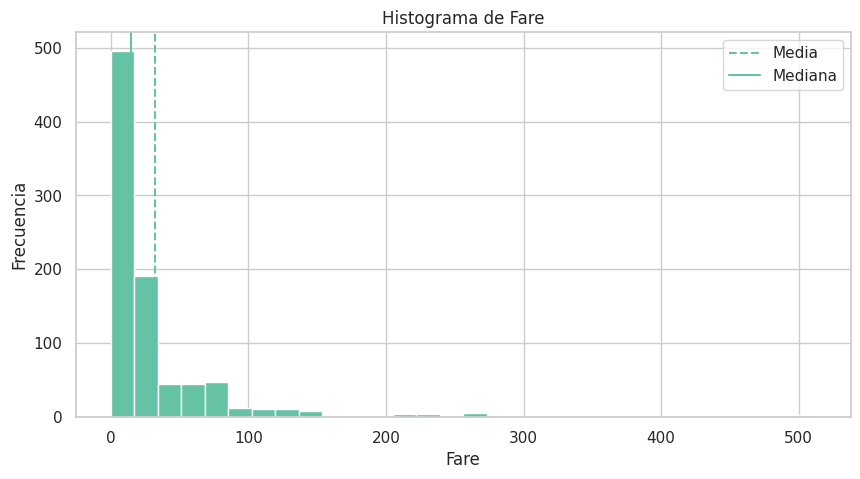

In [49]:
# PASO 3: Histograma
# TODO: histograma de Fare con bins=30 y líneas de media y mediana

import matplotlib.pyplot as plt

plt.figure()

plt.hist(df['Fare'], bins=30)

plt.axvline(df['Fare'].mean(), linestyle='dashed', label='Media')
plt.axvline(df['Fare'].median(), linestyle='solid', label='Mediana')

plt.title('Histograma de Fare')
plt.xlabel('Fare')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

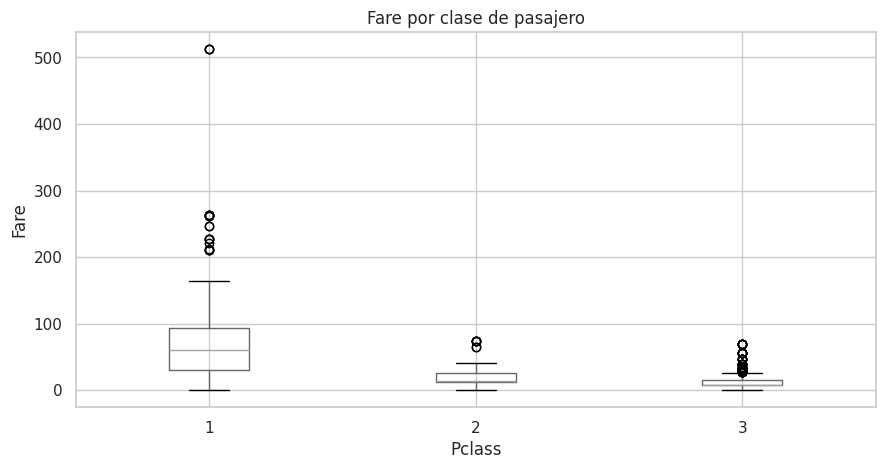

In [50]:
# PASO 4: Boxplot comparativo por Pclass
# TODO: boxplot de Fare agrupado por Pclass

import matplotlib.pyplot as plt

df.boxplot(column='Fare', by='Pclass')

plt.title('Fare por clase de pasajero')
plt.suptitle('')  # elimina título automático
plt.xlabel('Pclass')
plt.ylabel('Fare')

plt.show()

In [52]:
# PASO 5: Outliers
# TODO: aplicar detectar_outliers(df, 'Fare')

outliers_fare = detectar_outliers(df, 'Fare')

print("Cantidad de outliers:", len(outliers_fare))
print("Porcentaje:", round(len(outliers_fare) / len(df) * 100, 2), "%")

outliers_top5 = outliers_fare.nlargest(5, 'Fare')[['Name', 'Fare', 'Pclass']]

print("\nTop 5 outliers:")
print(outliers_top5.to_string(index=False))

Columna: Fare
  Q1=7.91  |  Q3=31.00  |  IQR=23.09
  Limite inferior: -26.72
  Limite superior: 65.63
  Outliers: 116 (13.0% del dataset)
  Valor maximo outlier: 512.33
  Valor minimo outlier: 66.60

Cantidad de outliers: 116
Porcentaje: 13.02 %

Top 5 outliers:
                              Name     Fare Pclass
                  Ward, Miss. Anna 512.3292      1
Cardeza, Mr. Thomas Drake Martinez 512.3292      1
            Lesurer, Mr. Gustave J 512.3292      1
    Fortune, Mr. Charles Alexander 263.0000      1
        Fortune, Miss. Mabel Helen 263.0000      1


### PASO 6: Conclusiones

*Escribí aquí tus 3 observaciones sobre la distribución de Fare:*

1- La distribución de Fare es asimétrica hacia la derecha, con muchos valores bajos y algunos valores altos.

2- Existen outliers (aproximadamente el 13% del dataset), que corresponden principalmente a pasajeros de primera clase.

3-Se observa una relación entre el precio del pasaje y la clase, donde la primera clase presenta valores más altos.

---
## 📋 Resumen: Funciones clave del laboratorio

| Función | Qué hace |
|---------|----------|
| `df.dtypes` | Ver tipo de cada columna |
| `df.info()` | Resumen completo: tipos, no-nulos, memoria |
| `df.describe()` | Estadísticas descriptivas numéricas |
| `df.describe(include=['object'])` | Estadísticas para columnas textuales |
| `col.astype(tipo)` | Convertir tipo de columna |
| `col.mean()` / `.median()` / `.mode()` | Tendencia central |
| `col.std()` / `.var()` | Dispersión |
| `col.quantile(0.25)` / `(0.75)` | Cuartiles Q1 y Q3 |
| `col.isnull().sum()` | Contar valores nulos |
| `plt.hist()` / `sns.histplot()` | Histograma |
| `plt.boxplot()` / `sns.boxplot()` | Diagrama de caja |
| `df.groupby(col).agg(funcs)` | Estadísticas por grupos |
| `pd.crosstab(col1, col2)` | Tabla de contingencia |

---
**Próxima clase:** Unidad 3 — Análisis Exploratorio y Multivariado (EDA)
- Correlación entre variables (Pearson, Spearman)
- Heatmaps de correlación
- Pairplots y análisis bivariado
- Proceso sistemático de EDA

*Completar todas las actividades TODO antes de la próxima clase.*